In [1]:
import pandas as pd
#para que salgan todas las columnas display max
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/csv/df_merged.csv')

In [2]:
df.head()

,date,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,FearGreed_Label,inflation,btc_mcap,eth_mcap,fed_rate
0,2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,1119.369995,1161.349976,984.818970,1036.790039,5261680128,0.334251,0.211308,0.454441,30.0,Fear,2.263469,1.703042e+11,1.076635e+11,1.42
1,2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,1035.770020,1035.770020,757.979980,915.784973,6713290240,0.339622,0.221066,0.439312,15.0,Extreme Fear,2.263469,1.527442e+11,9.942376e+10,1.42
2,2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,919.210999,991.942993,847.690002,964.018982,3243480064,0.350252,0.209758,0.439990,40.0,Fear,2.263469,1.487152e+11,8.906186e+10,1.42
3,2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7073549824,964.666992,969.031982,805.064026,834.682007,2997090048,0.341270,0.206612,0.452118,24.0,Extreme Fear,2.263469,1.515073e+11,9.172561e+10,1.42
4,2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9285289984,834.958008,856.645996,644.598999,697.950989,4269530112,0.351816,0.204261,0.443923,11.0,Extreme Fear,2.263469,1.400815e+11,8.132982e+10,1.42


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime

print("=" * 80)
print("AGREGACIÓN MENSUAL CON FEATURE ENGINEERING")
print("=" * 80)

# Cargar el df que ya tenemos
# df = pd.read_csv(r"C:\Users\josit\...\df_2018_2025.csv", parse_dates=['date'])

# PASO 1: ONE-HOT ENCODER para Fear & Greed Label
print("\n🔴 1. One-Hot Encoding Fear & Greed Label...")

# Crear mapping si la columna se llama diferente
if 'FearGreed_Label' in df.columns:
    fear_col = 'FearGreed_Label'
elif 'fear_greed_label' in df.columns:
    fear_col = 'fear_greed_label'
else:
    fear_col = [col for col in df.columns if 'label' in col.lower()][0]

# One-Hot Encoding con 0s y 1s (no True/False)

fear_encoded = pd.get_dummies(df[fear_col], prefix='fear')

# Convertir a int (0 y 1) en lugar de bool (True/False)
fear_encoded = fear_encoded.astype(int)

df_sorted = pd.concat([df, fear_encoded], axis=1)


AGREGACIÓN MENSUAL CON FEATURE ENGINEERING

🔴 1. One-Hot Encoding Fear & Greed Label...


In [4]:
df_sorted


,date,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,FearGreed_Label,inflation,btc_mcap,eth_mcap,fed_rate,fear_Extreme Fear,fear_Extreme Greed,fear_Fear,fear_Greed,fear_Neutral
0,2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,1119.369995,1161.349976,984.818970,1036.790039,5261680128,0.334251,0.211308,0.454441,30.0,Fear,2.263469,1.703042e+11,1.076635e+11,1.42,0,0,1,0,0
1,2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,1035.770020,1035.770020,757.979980,915.784973,6713290240,0.339622,0.221066,0.439312,15.0,Extreme Fear,2.263469,1.527442e+11,9.942376e+10,1.42,1,0,0,0,0
2,2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,919.210999,991.942993,847.690002,964.018982,3243480064,0.350252,0.209758,0.439990,40.0,Fear,2.263469,1.487152e+11,8.906186e+10,1.42,0,0,1,0,0
3,2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7073549824,964.666992,969.031982,805.064026,834.682007,2997090048,0.341270,0.206612,0.452118,24.0,Extreme Fear,2.263469,1.515073e+11,9.172561e+10,1.42,1,0,0,0,0
4,2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9285289984,834.958008,856.645996,644.598999,697.950989,4269530112,0.351816,0.204261,0.443923,11.0,Extreme Fear,2.263469,1.400815e+11,8.132982e+10,1.42,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2880,2025-12-21,88344.703125,89027.953125,87613.203125,88621.750000,19845522660,2977.508545,3009.807129,2945.394775,3001.613770,11178096676,0.572387,0.116629,0.310984,20.0,Extreme Fear,2.700000,1.762805e+12,3.591869e+11,3.84,1,0,0,0,0
2881,2025-12-22,88621.398438,90501.929688,87908.070312,88490.015625,38047472118,3001.612793,3073.353760,2965.175049,3006.073730,20342034264,0.573053,0.117441,0.309506,25.0,Extreme Fear,2.700000,1.768920e+12,3.625196e+11,3.84,1,0,0,0,0
2882,2025-12-23,88490.031250,88898.382812,86606.976562,87414.000000,43683011533,3006.073975,3033.196289,2902.333008,2963.374023,21453213168,0.573204,0.117729,0.309067,24.0,Extreme Fear,2.700000,1.767081e+12,3.629357e+11,3.84,1,0,0,0,0
2883,2025-12-24,87404.320312,87956.882812,86411.796875,87611.960938,25550297986,2962.922607,2975.171143,2888.988037,2945.590576,13984770325,0.573230,0.117515,0.309256,24.0,Extreme Fear,2.700000,1.745209e+12,3.577764e+11,3.84,1,0,0,0,0


In [9]:
# Si aún no es DatetimeIndex, forzar conversión
if not isinstance(df_sorted.index, pd.DatetimeIndex):
    df_sorted.index = pd.to_datetime(df_sorted.index)


In [19]:
import pandas as pd
import numpy as np

print("=" * 80)
print("AGREGACIÓN MENSUAL - VARIACIONES DE PRECIO Y VOLUMEN")
print("=" * 80)

# El df_merged ya existe, solo asegurar que date es datetime
df['date'] = pd.to_datetime(df['date'])

# Ordenar y setear índice
df_sorted = df.sort_values('date').set_index('date')

# Verificar rango
print(f"\nRango de datos: {df_sorted.index.min().date()} a {df_sorted.index.max().date()}")

# Crear columna de año-mes para agrupar
df_sorted['year_month'] = df_sorted.index.to_period('M')

print(f"Total de días: {len(df_sorted)}")
print(f"Primeros 3 días:\n{df_sorted[['btc_close', 'eth_close', 'FearGreed_Label', 'year_month']].head(3)}")

# Agrupar por mes
print("\n⏳ Agrupando por mes...")

df_monthly = df_sorted.groupby('year_month').agg({
    # VARIACIONES DE PRECIO (% desde primer día al último día del mes)
    'btc_close': lambda x: ((x.iloc[-1] / x.iloc[0]) - 1) * 100 if len(x) > 0 else np.nan,
    'eth_close': lambda x: ((x.iloc[-1] / x.iloc[0]) - 1) * 100 if len(x) > 0 else np.nan,
    'btc_open': 'first',
    'eth_open': 'first',
    
    # VARIACIONES DE VOLUMEN (% desde primer día al último día del mes)
    'btc_volume': lambda x: ((x.iloc[-1] / x.iloc[0]) - 1) * 100 if x.iloc[0] > 0 and len(x) > 0 else np.nan,
    'eth_volume': lambda x: ((x.iloc[-1] / x.iloc[0]) - 1) * 100 if x.iloc[0] > 0 and len(x) > 0 else np.nan,
    
    # VARIACIONES DE DOMINANCIA (puntos porcentuales: último - primer día)
    'btc_dominance': lambda x: (x.iloc[-1] - x.iloc[0]) * 100 if len(x) > 0 else np.nan,
    'eth_dominance': lambda x: (x.iloc[-1] - x.iloc[0]) * 100 if len(x) > 0 else np.nan,
    'alt_dominance': lambda x: (x.iloc[-1] - x.iloc[0]) * 100 if len(x) > 0 else np.nan,
    
    # SENTIMIENTO (promedio mensual)
    'fear_greed': 'mean',
    
    # MACRO (mantener último valor del mes)
    'inflation': 'last',
    'fed_rate': 'last'
})

# Renombrar columnas para claridad
df_monthly = df_monthly.rename(columns={
    'btc_close': 'btc_ret_monthly',
    'eth_close': 'eth_ret_monthly',
    'btc_volume': 'btc_volume_change',
    'eth_volume': 'eth_volume_change',
    'btc_dominance': 'btc_dominance_change',
    'eth_dominance': 'eth_dominance_change',
    'alt_dominance': 'alt_dominance_change'
})

# CONTAR OCURRENCIAS DE FEAR & GREED LABEL POR CATEGORÍA
print("   Contando Fear & Greed Labels por categoría...")

# Categorías posibles en FearGreed_Label
fear_categories = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# Contar cuántas veces aparece cada categoría por mes
for category in fear_categories:
    # Crear máscara booleana para esa categoría
    mask = df_sorted['FearGreed_Label'] == category
    
    # Contar por mes
    df_monthly[f'{category}_count'] = df_sorted[mask].groupby('year_month').size()
    
    # Rellenar meses sin esa categoría con 0
    df_monthly[f'{category}_count'] = df_monthly[f'{category}_count'].fillna(0).astype(int)

print(f"\n   ✅ Columnas Fear & Greed añadidas:")
fear_count_cols = [f'{cat}_count' for cat in fear_categories]
for col in fear_count_cols:
    print(f"      - {col}")

# Convertir índice Period a timestamp
df_monthly.index = df_monthly.index.to_timestamp()

# VERIFICACIÓN
print(f"\n✅ Agregación mensual completada")
print(f"   Total de meses: {len(df_monthly)}")
print(f"   Rango: {df_monthly.index.min().date()} a {df_monthly.index.max().date()}")

print(f"\n   Ejemplo de Fear & Greed counts (primer mes):")
print(df_monthly[fear_count_cols].head(3))

# PREPARAR FEATURES PARA K-MEANS
print("\n⚙️ Seleccionando features para K-means...")

features_kmeans = [
    'btc_ret_monthly', 'eth_ret_monthly',  # Variaciones de precio (%)
    'btc_volume_change', 'eth_volume_change',  # Variaciones de volumen (%)
    'btc_dominance_change', 'eth_dominance_change', 'alt_dominance_change',  # Cambios dominancia (pp)
    'fear_greed',  # Sentimiento promedio (0-100)
    'inflation', 'fed_rate'  # Macro (valores absolutos)
]

# Agregar Fear & Greed Label counts (cuentas de cada categoría)
features_kmeans.extend(fear_count_cols)

print(f"\n   Features seleccionadas ({len(features_kmeans)}):")
for i, feat in enumerate(features_kmeans, 1):
    print(f"      {i}. {feat}")

# Preparar X para K-means
X_monthly = df_monthly[features_kmeans].dropna()

print(f"\n   ✅ Dimensiones X_monthly: {X_monthly.shape}")
print(f"   Meses con datos completos: {len(X_monthly)}")

# ESTADÍSTICAS
print(f"\n📈 Descripción de features:")
print(X_monthly.describe())

print(f"\n   Primeras 10 filas:")
print(X_monthly.head(10))

print(f"\n   Últimas 10 filas:")
print(X_monthly.tail(10))

# Verificar continuidad mensual
meses_esperados = (2025 - 2018) * 12 + 11  # Feb 2018 a Dic 2025
print(f"\n✅ Verificación de continuidad:")
print(f"   Meses esperados aprox: {meses_esperados}")
print(f"   Meses en df_monthly: {len(df_monthly)}")
print(f"   Meses con datos completos (X_monthly): {len(X_monthly)}")

# GUARDAR
output_monthly = r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\data\kmeans_csv\df_monthly_kmeans.csv"
df_monthly.to_csv(output_monthly)
print(f"\n💾 df_monthly guardado en: {output_monthly}")

output_features = r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\data\kmeans_csv\X_monthly_kmeans.csv"
X_monthly.to_csv(output_features)
print(f"💾 X_monthly (features) guardado en: {output_features}")


AGREGACIÓN MENSUAL - VARIACIONES DE PRECIO Y VOLUMEN

Rango de datos: 2018-02-01 a 2025-12-25
Total de días: 2885
Primeros 3 días:
              btc_close    eth_close FearGreed_Label year_month
date                                                           
2018-02-01  9170.540039  1036.790039            Fear    2018-02
2018-02-02  8830.750000   915.784973    Extreme Fear    2018-02
2018-02-03  9174.910156   964.018982            Fear    2018-02

⏳ Agrupando por mes...
   Contando Fear & Greed Labels por categoría...

   ✅ Columnas Fear & Greed añadidas:
      - Extreme Fear_count
      - Fear_count
      - Neutral_count
      - Greed_count
      - Extreme Greed_count

✅ Agregación mensual completada
   Total de meses: 95
   Rango: 2018-02-01 a 2025-12-01

   Ejemplo de Fear & Greed counts (primer mes):
            Extreme Fear_count  Fear_count  Neutral_count  Greed_count  \
year_month                                                               
2018-02-01                   4      

In [20]:
df_monthly

,btc_ret_monthly,eth_ret_monthly,btc_open,eth_open,btc_volume_change,eth_volume_change,btc_dominance_change,eth_dominance_change,alt_dominance_change,fear_greed,inflation,fed_rate,Extreme Fear_count,Fear_count,Neutral_count,Greed_count,Extreme Greed_count
year_month,,,,,,,,,,,,,,,,,
2018-02-01,13.383730,-17.514739,10237.299805,1119.369995,-30.355346,-62.673899,6.117079,-2.530373,-3.586706,42.642857,2.263469,1.42,4,15,2,7,0
2018-03-01,-36.320612,-54.545174,10385.000000,856.012024,-37.773737,-29.146060,3.966949,-4.295937,0.328988,35.193548,2.330950,1.51,5,22,1,3,0
2018-04-01,35.012263,76.478311,7003.060059,397.253998,91.388535,126.989564,-7.674179,0.933002,6.741177,29.133333,2.470996,1.69,15,6,2,4,0
2018-05-01,-17.818161,-14.246750,9251.469727,670.463013,-33.526295,-25.902593,1.245980,1.285390,-2.531370,40.096774,2.781922,1.70,6,15,2,8,0
2018-06-01,-15.082645,-21.526513,7500.700195,578.671997,-7.672520,-24.150906,4.537511,0.421205,-4.958717,26.166667,2.807551,1.82,16,14,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,-4.485855,25.847434,115738.953125,3696.144287,-47.438043,-42.321344,-3.560823,2.101535,1.459289,57.838710,2.939220,4.33,0,2,11,18,0
2025-09-01,4.398596,-3.905756,108228.750000,4389.625977,-11.790039,0.395427,0.456734,-1.154793,0.698059,48.033333,3.022700,4.22,0,9,18,3,0
2025-10-01,-7.663588,-11.583980,114057.593750,4146.033691,-15.755683,-18.113654,1.109764,-0.192619,-0.917145,43.741935,2.789925,4.09,4,14,4,9,0


VISUALIZACIÓN DE VARIABLES COMO VECTORES (BIPLOT)

📊 Creando BIPLOT (puntos + vectores de variables)...
   ✅ Biplot guardado: biplot_variables.png


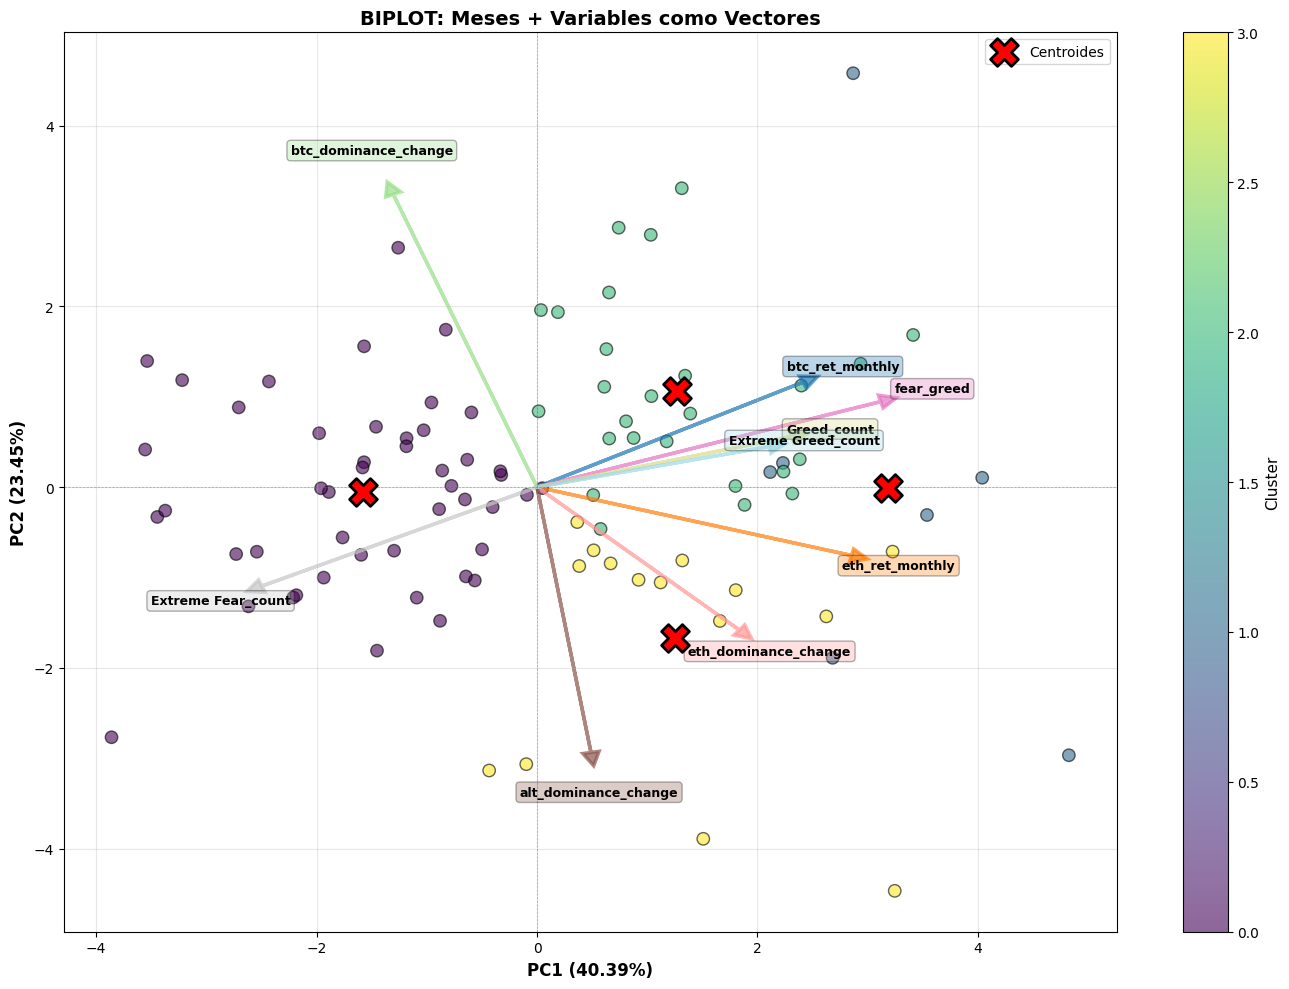


📋 LOADINGS (Contribución de variables a cada PC):

                         PC1     PC2
btc_ret_monthly       0.3596  0.2270
eth_ret_monthly       0.4253 -0.1480
btc_dominance_change -0.1943  0.6335
eth_dominance_change  0.2736 -0.3092
alt_dominance_change  0.0730 -0.5744
fear_greed            0.4648  0.1850
Extreme Fear_count   -0.3721 -0.2142
Greed_count           0.3446  0.1093
Extreme Greed_count   0.3140  0.0877

🔍 INTERPRETACIÓN:

PC1 (40.39%):
   Variables MÁS POSITIVAS (hacia la DERECHA):
      • fear_greed: 0.4648
      • eth_ret_monthly: 0.4253
      • btc_ret_monthly: 0.3596

   Variables MÁS NEGATIVAS (hacia la IZQUIERDA):
      • Extreme Fear_count: -0.3721
      • btc_dominance_change: -0.1943
      • alt_dominance_change: 0.0730

PC2 (23.45%):
   Variables MÁS POSITIVAS (hacia ARRIBA):
      • btc_dominance_change: 0.6335
      • btc_ret_monthly: 0.2270
      • fear_greed: 0.1850

   Variables MÁS NEGATIVAS (hacia ABAJO):
      • alt_dominance_change: -0.5744
      • et

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("VISUALIZACIÓN DE VARIABLES COMO VECTORES (BIPLOT)")
print("=" * 80)

# Cargar datos
X_monthly = pd.read_csv(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\data\kmeans_csv\X_monthly_kmeans.csv", 
                        index_col=0, parse_dates=True)

# Remover inflación y fed_rate
features_to_keep = [col for col in X_monthly.columns if col not in ['inflation', 'fed_rate', 'Neutral_count', 'Fear_count', 'eth_volume_change', 'btc_volume_change']]
X_monthly = X_monthly[features_to_keep]

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_monthly)

# PCA
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# K-means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# CREAR BIPLOT
print("\n📊 Creando BIPLOT (puntos + vectores de variables)...")

fig, ax = plt.subplots(figsize=(14, 10))

# Graficar puntos (meses) coloreados por cluster
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=clusters, cmap='viridis', s=80, alpha=0.6, edgecolors='black', linewidth=1)

# Centroides
centroides_pca = pca_2d.transform(kmeans.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], 
          c='red', s=400, marker='X', edgecolors='black', linewidth=2, label='Centroides', zorder=5)

# VECTORES DE VARIABLES (loadings)
loadings = pca_2d.components_.T * np.sqrt(pca_2d.explained_variance_)

# Escalar vectores para mejor visualización
scale_factor = 3.5
loadings_scaled = loadings * scale_factor

# Colores para los vectores
colors_vars = plt.cm.tab20(np.linspace(0, 1, len(X_monthly.columns)))

# Dibujar vectores
for i, (var_name, color) in enumerate(zip(X_monthly.columns, colors_vars)):
    ax.arrow(0, 0, 
            loadings_scaled[i, 0], loadings_scaled[i, 1],
            head_width=0.15, head_length=0.15, 
            fc=color, ec=color, alpha=0.7, linewidth=2.5)
    
    # Etiqueta del vector
    ax.text(loadings_scaled[i, 0] * 1.15, loadings_scaled[i, 1] * 1.15,
           var_name, fontsize=9, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3),
           ha='center', va='center')

# Línea de origen
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12, fontweight='bold')
ax.set_title('BIPLOT: Meses + Variables como Vectores', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster', fontsize=11)

ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\results\biplot_variables.png", 
            dpi=300, bbox_inches='tight')
print(f"   ✅ Biplot guardado: biplot_variables.png")
plt.show()

# TABLA DE LOADINGS (qué significa cada vector)
print("\n📋 LOADINGS (Contribución de variables a cada PC):")
print("\n" + "=" * 80)

loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=X_monthly.columns
)

print(loadings_df.round(4))

print("\n🔍 INTERPRETACIÓN:")
print(f"\nPC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%):")
print("   Variables MÁS POSITIVAS (hacia la DERECHA):")
top_pc1_pos = loadings_df['PC1'].nlargest(3)
for var, val in top_pc1_pos.items():
    print(f"      • {var}: {val:.4f}")

print("\n   Variables MÁS NEGATIVAS (hacia la IZQUIERDA):")
top_pc1_neg = loadings_df['PC1'].nsmallest(3)
for var, val in top_pc1_neg.items():
    print(f"      • {var}: {val:.4f}")

print(f"\nPC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%):")
print("   Variables MÁS POSITIVAS (hacia ARRIBA):")
top_pc2_pos = loadings_df['PC2'].nlargest(3)
for var, val in top_pc2_pos.items():
    print(f"      • {var}: {val:.4f}")

print("\n   Variables MÁS NEGATIVAS (hacia ABAJO):")
top_pc2_neg = loadings_df['PC2'].nsmallest(3)
for var, val in top_pc2_neg.items():
    print(f"      • {var}: {val:.4f}")

print("\n" + "=" * 80)
print("✅ BIPLOT COMPLETADO")
print("=" * 80)


✅ Carpeta creada/verificada: C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\results
PCA + K-MEANS CLUSTERING

📊 PASO 1: Cargando datos...
   Filas (meses): 95
   Columnas (features): 8
   Features: ['btc_ret_monthly', 'eth_ret_monthly', 'btc_dominance_change', 'eth_dominance_change', 'alt_dominance_change', 'fear_greed', 'Extreme Fear_count', 'Extreme Greed_count']

🔧 PASO 2: Normalizando features (StandardScaler)...
   ✅ Datos normalizados (media=0, std=1)

📉 PASO 3: Calculando PCA...

   Varianza explicada por componente:
      PC1: 41.12% (acumulada: 41.12%)
      PC2: 26.11% (acumulada: 67.23%)
      PC3: 15.07% (acumulada: 82.31%)
      PC4: 9.91% (acumulada: 92.21%)
      PC5: 6.58% (acumulada: 98.79%)

🎨 PASO 4: Reduciendo a 2 componentes para visualización...
   PC1 explica: 41.12%
   PC2 explica: 26.11%
   Total: 67.23%

🎯 PASO 5: Aplicando K-means...

   Usando K = 3 clusters
   ✅ Clustering completado
   Distribución de clusters:
      Cluster 0: 51 meses
      Cluster 1: 33

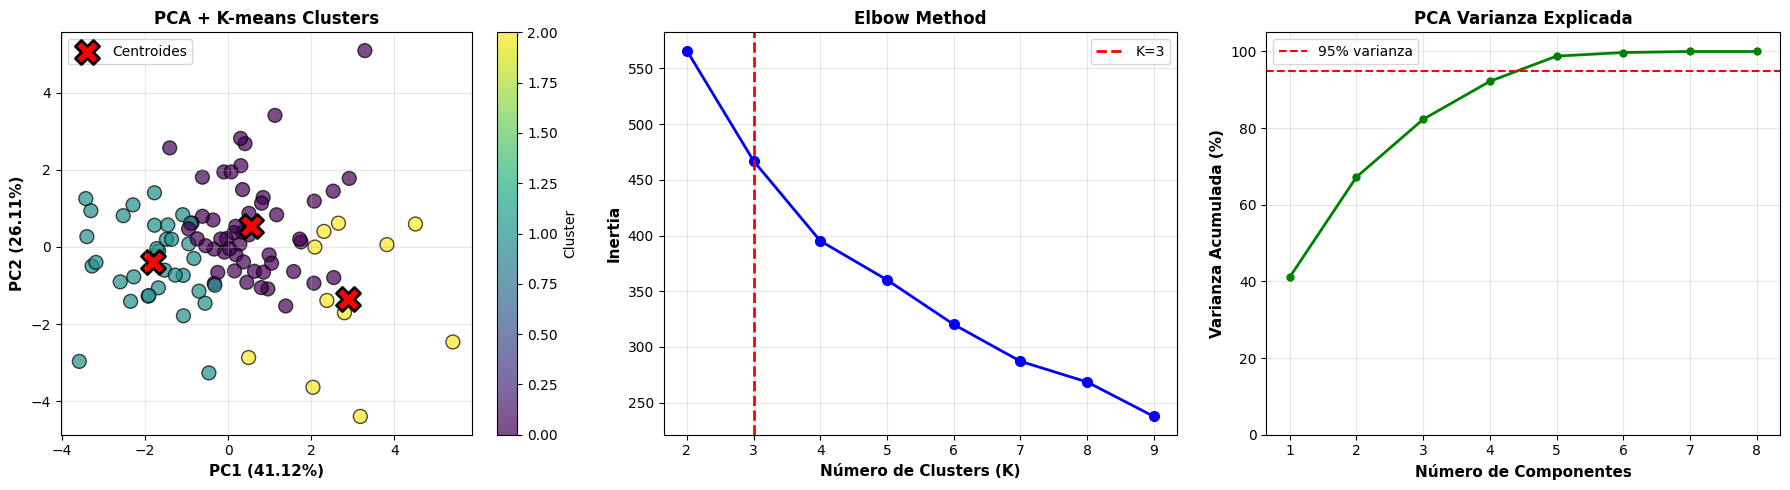

In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

# Crear carpeta results si no existe
results_dir = r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\results"
os.makedirs(results_dir, exist_ok=True)
print(f"✅ Carpeta creada/verificada: {results_dir}")


print("=" * 80)
print("PCA + K-MEANS CLUSTERING")
print("=" * 80)

# PASO 1: CARGAR DATOS
print("\n📊 PASO 1: Cargando datos...")
X_monthly = pd.read_csv(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\data\kmeans_csv\X_monthly_kmeans.csv", 
                        index_col=0, parse_dates=True)

features_to_keep = [col for col in X_monthly.columns if col not in ['Greed_count', 'inflation', 'fed_rate', 'Neutral_count', 'Fear_count', 'eth_volume_change', 'btc_volume_change']]
X_monthly = X_monthly[features_to_keep]

print(f"   Filas (meses): {X_monthly.shape[0]}")
print(f"   Columnas (features): {X_monthly.shape[1]}")
print(f"   Features: {list(X_monthly.columns)}")

# PASO 2: NORMALIZAR (CRÍTICO)
print("\n🔧 PASO 2: Normalizando features (StandardScaler)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_monthly)

print(f"   ✅ Datos normalizados (media=0, std=1)")

# PASO 3: CALCULAR PCA
print("\n📉 PASO 3: Calculando PCA...")
pca = PCA()
pca.fit(X_scaled)

# Varianza explicada
var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

print(f"\n   Varianza explicada por componente:")
for i in range(min(5, len(var_explicada))):
    print(f"      PC{i+1}: {var_explicada[i]*100:.2f}% (acumulada: {var_acumulada[i]*100:.2f}%)")

# PASO 4: PROYECTAR A 2D (para visualizar)
print("\n🎨 PASO 4: Reduciendo a 2 componentes para visualización...")
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"   PC1 explica: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2 explica: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

# PASO 5: K-MEANS CLUSTERING
print("\n🎯 PASO 5: Aplicando K-means...")

# Determinar número óptimo de clusters (elbow method)
inertias = []
K_range = range(2, 10)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

# Usar 4 clusters (puedes cambiar si lo necesitas)
optimal_k = 3
print(f"\n   Usando K = {optimal_k} clusters")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print(f"   ✅ Clustering completado")
print(f"   Distribución de clusters:")
for i in range(optimal_k):
    count = np.sum(clusters == i)
    print(f"      Cluster {i}: {count} meses")

# PASO 6: CREAR DATAFRAME CON RESULTADOS
print("\n📋 PASO 6: Creando DataFrame con resultados...")

df_results = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': clusters
}, index=X_monthly.index)

print(f"\n   Primeras filas:")
print(df_results.head())

# PASO 7: VISUALIZAR
print("\n📊 PASO 7: Creando gráficos...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: PCA + Clusters
ax1 = axes[0]
scatter = ax1.scatter(df_results['PC1'], df_results['PC2'], 
                     c=df_results['Cluster'], cmap='viridis', s=100, alpha=0.7, edgecolors='black')
# Centroides
centroides_pca = pca_2d.transform(kmeans.cluster_centers_)
ax1.scatter(centroides_pca[:, 0], centroides_pca[:, 1], 
           c='red', s=300, marker='X', edgecolors='black', linewidth=2, label='Centroides')
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)', fontsize=11, fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)', fontsize=11, fontweight='bold')
ax1.set_title('PCA + K-means Clusters', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Cluster', fontsize=10)
ax1.legend()

# Gráfico 2: Elbow curve
ax2 = axes[1]
ax2.plot(K_range, inertias, 'b-o', linewidth=2, markersize=7)
ax2.axvline(x=optimal_k, color='r', linestyle='--', linewidth=2, label=f'K={optimal_k}')
ax2.set_xlabel('Número de Clusters (K)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Inertia', fontsize=11, fontweight='bold')
ax2.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Gráfico 3: Varianza acumulada
ax3 = axes[2]
ax3.plot(range(1, len(var_acumulada)+1), var_acumulada*100, 'g-o', linewidth=2, markersize=5)
ax3.axhline(y=95, color='r', linestyle='--', label='95% varianza')
ax3.set_xlabel('Número de Componentes', fontsize=11, fontweight='bold')
ax3.set_ylabel('Varianza Acumulada (%)', fontsize=11, fontweight='bold')
ax3.set_title('PCA Varianza Explicada', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_ylim([0, 105])

plt.tight_layout()
plt.savefig(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\results\pca_kmeans_analysis.png", 
            dpi=300, bbox_inches='tight')
print(f"   ✅ Gráfico guardado: pca_kmeans_analysis.png")
plt.show()


In [ ]:

# PASO 8: INTERPRETAR CLUSTERS
print("\n🔍 PASO 8: Interpretación de clusters...")

df_interpretation = X_monthly.copy()
df_interpretation['Cluster'] = clusters

print(f"\n   Características por cluster:")
for i in range(optimal_k):
    print(f"\n   CLUSTER {i}:")
    cluster_data = df_interpretation[df_interpretation['Cluster'] == i].drop('Cluster', axis=1)
    print(cluster_data.describe().loc[['mean', 'std']])



🔍 PASO 8: Interpretación de clusters...

   Características por cluster:

   CLUSTER 0:

   CLUSTER 1:

   CLUSTER 2:

   CLUSTER 3:


In [ ]:

# PASO 9: GUARDAR RESULTADOS
print("\n💾 PASO 9: Guardando resultados...")

df_results.to_csv(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\results\kmeans_results.csv")
print(f"   ✅ Resultados guardados: kmeans_results.csv")

df_interpretation.to_csv(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_Crypto_DEF\results\df_with_clusters.csv")
print(f"   ✅ DataFrame con clusters: df_with_clusters.csv")

print("\n" + "=" * 80)
print("✅ PCA + K-MEANS COMPLETADO")
print("=" * 80)
